In [ ]:
from ultralytics import YOLO

model = YOLO("models/best.pt")

results = model("test.mp4", save=True)
print(results[0])
print('=====================================')
for box in results[0].boxes:
    print(box)

In [ ]:
from ultralytics import YOLO
import cv2
import torch
import numpy as np

def main():
    # Initialize the model
    model = YOLO("models/best.pt")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    # Comment out the half-precision conversion
    # if device.type == 'cuda':
    #     model.model.half()

    cap = cv2.VideoCapture("test.mp4")
    batch_size = 8
    frames = []
    results_list = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

        if len(frames) == batch_size:
            results = model(frames, device=device)
            results_list.extend(results)
            frames = []

    if frames:
        results = model(frames, device=device)
        results_list.extend(results)

    cap.release()


if __name__ == "__main__":
    main()


In [ ]:
from ultralytics import YOLO
import cv2
import torch
import numpy as np
import supervision as sv

def main():
    model = YOLO("models/best.pt")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    cap = cv2.VideoCapture("test.mp4")
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    out = cv2.VideoWriter('basic_annotated_frame.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

    batch_size = 8
    frames = []
    frame_indices = []
    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)
        frame_indices.append(frame_count)
        frame_count += 1

        if len(frames) == batch_size:
            results = model(frames, device=device)
            for i, result in enumerate(results):
                

                annotated_frame = result.plot()
                annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_RGB2BGR)

                out.write(annotated_frame)

            frames = []
            frame_indices = []

    if frames:
        results = model(frames, device=device)
        for i, result in enumerate(results):
            annotated_frame = result.plot()
            annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_RGB2BGR)
            out.write(annotated_frame)

    cap.release()
    out.release()

if __name__ == "__main__":
    main()


In [ ]:
from ultralytics import YOLO
import supervision as sv
import torch
import cv2

# Set up GPU device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize YOLO model on GPU
model = YOLO("models/best.pt")
model.to(device)

ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)
triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#FFD700'),
    base=25,
    height=21,
    outline_thickness=1
)

tracker = sv.ByteTrack()
tracker.reset()

# Video input and output
SOURCE_VIDEO_PATH = "test.mp4"
OUTPUT_VIDEO_PATH = "clip_with_annotated_players_using_supervision.mp4"

cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

batch_size = 16
frames = []
BALL_ID = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame_rgb)

    if len(frames) == batch_size:
        # Run YOLO inference on batch
        results = model(frames, device=device)

        for i, result in enumerate(results):
            # Convert YOLO outputs to Supervision Detections
            detections = sv.Detections(
                xyxy=result.boxes.xyxy.cpu().numpy(),
                confidence=result.boxes.conf.cpu().numpy(),
                class_id=result.boxes.cls.cpu().numpy().astype(int)
            )

            ball_detections = detections[detections.class_id == BALL_ID]
            ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)

            all_detections = detections[detections.class_id != BALL_ID]
            all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True)
            all_detections.class_id -= 1
            all_detections = tracker.update_with_detections(detections=all_detections)

            labels =[
                f"#{tracker_id}"
                for tracker_id
                in all_detections.tracker_id
            ]

            frame_bgr = cv2.cvtColor(frames[i], cv2.COLOR_RGB2BGR)
            annotated_frame = ellipse_annotator.annotate(
                scene=frame_bgr,
                detections=all_detections
            )
            annotated_frame = label_annotator.annotate(
                scene=annotated_frame,
                detections=all_detections,
                labels=labels
            )
            annotated_frame = triangle_annotator.annotate(
                scene=annotated_frame,
                detections=ball_detections
            )

            # Write annotated frame to output video
            out.write(annotated_frame)

        # Clear processed frames
        frames = []



cap.release()
out.release()


In [ ]:
from ultralytics import YOLO
import supervision as sv
import torch
import cv2
from utils.team_classifier import TeamClassifier
from tqdm import tqdm
import numpy as np



# Set up GPU device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize YOLO model on GPU
model = YOLO("models/best.pt")
model.to(device)

ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)
triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#FFD700'),
    base=25,
    height=21,
    outline_thickness=1
)

def resolve_goalkeepers_team_id(
    players: sv.Detections,
    goalkeepers: sv.Detections
) -> np.ndarray:
    goalkeepers_xy = goalkeepers.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
    players_xy = players.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
    team_0_centroid = players_xy[players.class_id == 0].mean(axis=0)
    team_1_centroid = players_xy[players.class_id == 1].mean(axis=0)
    goalkeepers_team_id = []
    for goalkeeper_xy in goalkeepers_xy:
        dist_0 = np.linalg.norm(goalkeeper_xy - team_0_centroid)
        dist_1 = np.linalg.norm(goalkeeper_xy - team_1_centroid)
        goalkeepers_team_id.append(0 if dist_0 < dist_1 else 1)

    return np.array(goalkeepers_team_id)


tracker = sv.ByteTrack()
tracker.reset()

# Video input and output
SOURCE_VIDEO_PATH = "test.mp4"
OUTPUT_VIDEO_PATH = "slow_with_team_classifier.mp4"

cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

batch_size = 16
frames = []
BALL_ID = 0
GOALKEEPER_ID = 1
PLAYER_ID = 2
REFEREE_ID = 3
crops = []



PLAYER_ID = 2
STRIDE = 30
frame_generator = sv.get_video_frames_generator(
    source_path=SOURCE_VIDEO_PATH, stride=STRIDE)

crops = []
for frame in tqdm(frame_generator, desc='collecting crops'):
    results = model(frame, device=device)
    result = results[0]  # Access the first result
    detections = sv.Detections(
        xyxy=result.boxes.xyxy.cpu().numpy(),
        confidence=result.boxes.conf.cpu().numpy(),
        class_id=result.boxes.cls.cpu().numpy().astype(int)
    )
    # Extract player detections
    players_detections = detections[detections.class_id == PLAYER_ID]
    # Extract crops corresponding to player detections
    players_crops = [sv.crop_image(frame, xyxy) for xyxy in players_detections.xyxy]
    crops += players_crops

team_classifier = TeamClassifier(device="cuda")
team_classifier.fit(crops)


while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame_rgb)

    if len(frames) == batch_size:
        # Run YOLO inference on batch
        results = model(frames, device=device)
        

        for i, result in enumerate(results):
            # Convert YOLO outputs to Supervision Detections
            detections = sv.Detections(
                xyxy=result.boxes.xyxy.cpu().numpy(),
                confidence=result.boxes.conf.cpu().numpy(),
                class_id=result.boxes.cls.cpu().numpy().astype(int)
            )

            ball_detections = detections[detections.class_id == BALL_ID]
            ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)

            all_detections = detections[detections.class_id != BALL_ID]
            all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True)
            all_detections = tracker.update_with_detections(detections=all_detections)

            goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
            players_detections = all_detections[all_detections.class_id == PLAYER_ID]
            referees_detections = all_detections[all_detections.class_id == REFEREE_ID]
            players_crops = [sv.crop_image(frames[i], xyxy) for xyxy in players_detections.xyxy]


            players_detections.class_id = team_classifier.predict(players_crops)                
            
            goalkeepers_detections.class_id = resolve_goalkeepers_team_id(
                players_detections, goalkeepers_detections)
            referees_detections.class_id -= 1

            all_detections = sv.Detections.merge([
                players_detections, goalkeepers_detections, referees_detections])


            labels =[
                f"#{tracker_id}"
                for tracker_id
                in all_detections.tracker_id
            ]

            all_detections.class_id = all_detections.class_id.astype(int)


            frame_bgr = cv2.cvtColor(frames[i], cv2.COLOR_RGB2BGR)
            annotated_frame = ellipse_annotator.annotate(
                scene=frame_bgr,
                detections=all_detections
            )
            annotated_frame = label_annotator.annotate(
                scene=annotated_frame,
                detections=all_detections,
                labels=labels
            )
            annotated_frame = triangle_annotator.annotate(
                scene=annotated_frame,
                detections=ball_detections
            )

            # Write annotated frame to output video
            out.write(annotated_frame)

        # Clear processed frames
        frames = []



cap.release()
out.release()

#batch size 8 = 2 mins 22 seconds
#batch size 16 = 2 min 12 seconds


In [ ]:
from ultralytics import YOLO
import supervision as sv
import torch
import cv2
from utils.team_classifier import TeamClassifier
from tqdm import tqdm
import numpy as np



# Set up GPU device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize YOLO model on GPU
model = YOLO("models/best.pt")
model.to(device)

ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)
triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#FFD700'),
    base=25,
    height=21,
    outline_thickness=1
)

def resolve_goalkeepers_team_id(
    players: sv.Detections,
    goalkeepers: sv.Detections
) -> np.ndarray:
    goalkeepers_xy = goalkeepers.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
    players_xy = players.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
    team_0_centroid = players_xy[players.class_id == 0].mean(axis=0)
    team_1_centroid = players_xy[players.class_id == 1].mean(axis=0)
    goalkeepers_team_id = []
    for goalkeeper_xy in goalkeepers_xy:
        dist_0 = np.linalg.norm(goalkeeper_xy - team_0_centroid)
        dist_1 = np.linalg.norm(goalkeeper_xy - team_1_centroid)
        goalkeepers_team_id.append(0 if dist_0 < dist_1 else 1)

    return np.array(goalkeepers_team_id)


tracker = sv.ByteTrack()
tracker.reset()

# Video input and output
SOURCE_VIDEO_PATH = "test.mp4"
OUTPUT_VIDEO_PATH = "QuickWithTeamClassifier.mp4"

cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

batch_size = 16
frames = []
BALL_ID = 0
GOALKEEPER_ID = 1
PLAYER_ID = 2
REFEREE_ID = 3
crops = []



PLAYER_ID = 2
STRIDE = 30
frame_generator = sv.get_video_frames_generator(
    source_path=SOURCE_VIDEO_PATH, stride=STRIDE)

crops = []
for frame in tqdm(frame_generator, desc='collecting crops'):
    results = model(frame, device=device)
    result = results[0]  # Access the first result
    detections = sv.Detections(
        xyxy=result.boxes.xyxy.cpu().numpy(),
        confidence=result.boxes.conf.cpu().numpy(),
        class_id=result.boxes.cls.cpu().numpy().astype(int)
    )
    # Extract player detections
    players_detections = detections[detections.class_id == PLAYER_ID]
    # Extract crops corresponding to player detections
    players_crops = [sv.crop_image(frame, xyxy) for xyxy in players_detections.xyxy]
    crops += players_crops

team_classifier = TeamClassifier(device="cuda")
team_classifier.fit(crops)


# Initialize the team assignments cache
team_assignments = {}

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame_rgb)

    if len(frames) == batch_size:
        # Run YOLO inference on batch
        results = model(frames, device=device)

        for i, result in enumerate(results):
            # Convert YOLO outputs to Supervision Detections
            detections = sv.Detections(
                xyxy=result.boxes.xyxy.cpu().numpy(),
                confidence=result.boxes.conf.cpu().numpy(),
                class_id=result.boxes.cls.cpu().numpy().astype(int)
            )

            # Get all detections and update tracker IDs
            all_detections = detections[detections.class_id != BALL_ID]
            all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True)
            all_detections = tracker.update_with_detections(detections=all_detections)

            # Separate detections by class
            ball_detections = detections[detections.class_id == BALL_ID]
            ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)
            goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
            players_detections = all_detections[all_detections.class_id == PLAYER_ID]
            referees_detections = all_detections[all_detections.class_id == REFEREE_ID]

            # Initialize lists to collect data
            new_crops = []
            new_tracker_ids = []
            assigned_classes = []

            for idx, (xyxy, tracker_id) in enumerate(zip(players_detections.xyxy, players_detections.tracker_id)):
                # Check if tracker_id is in cache
                if tracker_id in team_assignments:
                    # Assign cached class_id
                    assigned_classes.append(team_assignments[tracker_id])
                else:
                    # Extract crop for new player
                    crop = sv.crop_image(frames[i], xyxy)
                    new_crops.append(crop)
                    new_tracker_ids.append(tracker_id)
                    assigned_classes.append(None)  # Placeholder for now

            # Predict team classification for new crops
            if new_crops:
                # Batch predict team classifications
                new_classes = team_classifier.predict(new_crops)
                # Update cache and assigned_classes
                for idx, (tracker_id, class_id) in enumerate(zip(new_tracker_ids, new_classes)):
                    team_assignments[tracker_id] = class_id
                    # Update assigned_classes in the correct positions
                    assigned_classes[assigned_classes.index(None)] = class_id

            # Assign the class IDs to players_detections
            players_detections.class_id = np.array(assigned_classes)

            # Resolve goalkeepers' team IDs
            goalkeepers_detections.class_id = resolve_goalkeepers_team_id(
                players_detections, goalkeepers_detections)
            referees_detections.class_id -= 1

            # Merge detections
            all_detections = sv.Detections.merge([
                players_detections, goalkeepers_detections, referees_detections])

            # Generate labels
            labels = [
                f"#{tracker_id}"
                for tracker_id in all_detections.tracker_id
            ]

            all_detections.class_id = all_detections.class_id.astype(int)

            frame_bgr = cv2.cvtColor(frames[i], cv2.COLOR_RGB2BGR)
            annotated_frame = ellipse_annotator.annotate(
                scene=frame_bgr,
                detections=all_detections
            )
            annotated_frame = label_annotator.annotate(
                scene=annotated_frame,
                detections=all_detections,
                labels=labels
            )
            annotated_frame = triangle_annotator.annotate(
                scene=annotated_frame,
                detections=ball_detections
            )

            # Write annotated frame to output video
            out.write(annotated_frame)

        # Clear processed frames
        frames = []

cap.release()
out.release()


###Average color classifier

In [ ]:
# Import necessary libraries
import cv2
import numpy as np
from ultralytics import YOLO
import supervision as sv
import torch
from tqdm import tqdm
from sklearn.cluster import KMeans

# Set up GPU device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize YOLO model on GPU
model = YOLO("models/players_detection.pt")
model.to(device)

# Define annotators for visualization
ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)
triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#FFD700'),
    base=25,
    height=21,
    outline_thickness=1
)

# Constants for class IDs
BALL_ID = 0
GOALKEEPER_ID = 1
PLAYER_ID = 2
REFEREE_ID = 3

# Video input and output paths
SOURCE_VIDEO_PATH = "test.mp4"
OUTPUT_VIDEO_PATH = "quick_with_team_classifier_version2.mp4"

# Open video capture and writer
cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

# Function to extract average color from an image crop
def extract_average_color(image):
    # Convert image to HSV
    image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # Resize to reduce computation
    image = cv2.resize(image, (32, 32))
    # Compute the mean color
    mean_color = image.mean(axis=(0, 1))
    return mean_color

# Function to classify player based on dominant color
def classify_player(dominant_color, team_colors):
    # Compute distances to each team color
    distances = np.linalg.norm(team_colors - dominant_color, axis=1)
    # Assign to the closest team
    team_id = np.argmin(distances)
    return team_id

# Collect initial frames to determine team colors
initial_frames = []
STRIDE = 30  # You can adjust the stride to control how many frames to skip
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Collect frames at intervals to sample player colors
for idx in range(0, frame_count, STRIDE):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if not ret:
        break
    initial_frames.append(frame)
    if len(initial_frames) >= 10:  # Limit the number of frames for initialization
        break

# Collect dominant colors from initial frames
dominant_colors = []
print("Collecting dominant colors from initial frames...")
for frame in tqdm(initial_frames):
    results = model(frame, device=device)
    result = results[0]
    detections = sv.Detections(
        xyxy=result.boxes.xyxy.cpu().numpy(),
        confidence=result.boxes.conf.cpu().numpy(),
        class_id=result.boxes.cls.cpu().numpy().astype(int)
    )
    players_detections = detections[detections.class_id == PLAYER_ID]
    for xyxy in players_detections.xyxy:
        crop = sv.crop_image(frame, xyxy)
        dominant_color = extract_average_color(crop)
        dominant_colors.append(dominant_color)

# Cluster the dominant colors to find team colors
print("Clustering colors to identify team colors...")
dominant_colors = np.array(dominant_colors)
kmeans = KMeans(n_clusters=2)
kmeans.fit(dominant_colors)
team_colors = kmeans.cluster_centers_

# Reset the video capture to the beginning
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Initialize frame buffer
frames = []
batch_size = 16  # Adjust batch size as needed

print("Processing video and classifying players...")
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame_rgb)

    if len(frames) == batch_size:
        # Run YOLO inference on batch
        results = model(frames, device=device)

        for i, result in enumerate(results):
            # Convert YOLO outputs to Supervision Detections
            detections = sv.Detections(
                xyxy=result.boxes.xyxy.cpu().numpy(),
                confidence=result.boxes.conf.cpu().numpy(),
                class_id=result.boxes.cls.cpu().numpy().astype(int)
            )

            # Separate detections by class
            ball_detections = detections[detections.class_id == BALL_ID]
            ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)
            all_detections = detections[detections.class_id != BALL_ID]

            # Apply Non-Maximum Suppression
            all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True)

            # Separate player, goalkeeper, and referee detections
            goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
            players_detections = all_detections[all_detections.class_id == PLAYER_ID]
            referees_detections = all_detections[all_detections.class_id == REFEREE_ID]

            # Extract crops and classify players
            team_ids = []
            for xyxy in players_detections.xyxy:
                crop = sv.crop_image(frames[i], xyxy)
                dominant_color = extract_average_color(crop)
                team_id = classify_player(dominant_color, team_colors)
                team_ids.append(team_id)

            # Assign team IDs to player detections
            players_detections.class_id = np.array(team_ids)

            # Assign team IDs to goalkeepers based on proximity to team centroids
            def resolve_goalkeepers_team_id(players, goalkeepers):
                if len(goalkeepers) == 0 or len(players) == 0:
                    return np.array([])
                goalkeepers_xy = goalkeepers.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
                players_xy = players.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
                team_0_players = players_xy[np.array(players.class_id) == 0]
                team_1_players = players_xy[np.array(players.class_id) == 1]
                team_0_centroid = team_0_players.mean(axis=0) if len(team_0_players) > 0 else np.array([0, 0])
                team_1_centroid = team_1_players.mean(axis=0) if len(team_1_players) > 0 else np.array([0, 0])
                goalkeepers_team_id = []
                for goalkeeper_xy in goalkeepers_xy:
                    dist_0 = np.linalg.norm(goalkeeper_xy - team_0_centroid)
                    dist_1 = np.linalg.norm(goalkeeper_xy - team_1_centroid)
                    if dist_0 == dist_1:
                        # Assign to a default team if equidistant
                        goalkeepers_team_id.append(0)
                    else:
                        goalkeepers_team_id.append(0 if dist_0 < dist_1 else 1)
                return np.array(goalkeepers_team_id)

            # Assign team IDs to goalkeepers
            goalkeepers_detections.class_id = resolve_goalkeepers_team_id(players_detections, goalkeepers_detections)

            # Adjust class IDs for referees (if needed)
            # Assuming referees have a unique class ID and do not need team assignment

            # Merge detections
            all_detections = sv.Detections.merge([
                players_detections, goalkeepers_detections, referees_detections
            ])

            # Generate labels (e.g., class names or IDs)
            labels = [
                f"ID: {idx}" for idx in range(len(all_detections.xyxy))
            ]

            # Ensure class IDs are integers
            all_detections.class_id = all_detections.class_id.astype(int)

            # Annotate the frame
            frame_bgr = cv2.cvtColor(frames[i], cv2.COLOR_RGB2BGR)
            annotated_frame = ellipse_annotator.annotate(
                scene=frame_bgr,
                detections=all_detections
            )
            # annotated_frame = label_annotator.annotate(
            #     scene=annotated_frame,
            #     detections=all_detections,
            #     labels=labels
            # )
            annotated_frame = triangle_annotator.annotate(
                scene=annotated_frame,
                detections=ball_detections
            )

            # Write annotated frame to output video
            out.write(annotated_frame)

        # Clear processed frames
        frames = []

# Release resources
cap.release()
out.release()
print("Processing complete. Output video saved to:", OUTPUT_VIDEO_PATH)


In [3]:
# Import necessary libraries
import cv2
import numpy as np
from ultralytics import YOLO
import supervision as sv
import torch
from tqdm import tqdm
from sklearn.cluster import KMeans

# Set up GPU device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize YOLO model on GPU
model = YOLO("models/players_detection.pt")
model.to(device)

# Define annotators for visualization
ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)
triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#FFD700'),
    base=25,
    height=21,
    outline_thickness=1
)

# Constants for class IDs (assuming your model's class order)
BALL_ID = 0
GOALKEEPER_ID = 1
PLAYER_ID = 2
REFEREE_ID = 3

# Video input and output paths
SOURCE_VIDEO_PATH = "test.mp4"
OUTPUT_VIDEO_PATH = "ball_possesion.mp4"

# Open video capture and writer
cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

# Function to extract average color from an image crop
def extract_average_color(image):
    # Convert image to HSV
    image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # Resize to reduce computation and noise
    image = cv2.resize(image, (32, 32))
    # Compute the mean color
    mean_color = image.mean(axis=(0, 1))
    return mean_color

# Function to classify player based on dominant color
def classify_player(dominant_color, team_colors):
    # Compute distances to each team color centroid
    distances = np.linalg.norm(team_colors - dominant_color, axis=1)
    # Assign to the closest team
    team_id = np.argmin(distances)
    return team_id

def get_center(box):
    # box format: [x_min, y_min, x_max, y_max]
    x_center = (box[0] + box[2]) / 2
    y_center = (box[1] + box[3]) / 2
    return np.array([x_center, y_center])

# Collect initial frames to determine team colors
initial_frames = []
STRIDE = 30  # adjust the stride to control how many frames to skip
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Collect frames at intervals to sample player colors
for idx in range(0, frame_count, STRIDE):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if not ret:
        break
    initial_frames.append(frame)
    if len(initial_frames) >= 10:  # Limit the number of frames for initialization
        break

# Collect dominant colors from initial frames
dominant_colors = []
print("Collecting dominant colors from initial frames...")
for frame in tqdm(initial_frames):
    results = model(frame, device=device)
    result = results[0]
    detections = sv.Detections(
        xyxy=result.boxes.xyxy.cpu().numpy(),
        confidence=result.boxes.conf.cpu().numpy(),
        class_id=result.boxes.cls.cpu().numpy().astype(int)
    )
    players_detections = detections[detections.class_id == PLAYER_ID]
    for xyxy in players_detections.xyxy:
        crop = sv.crop_image(frame, xyxy)
        dominant_color = extract_average_color(crop)
        dominant_colors.append(dominant_color)

# Cluster the dominant colors to find team colors
print("Clustering colors to identify team colors...")
dominant_colors = np.array(dominant_colors)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(dominant_colors)
team_colors = kmeans.cluster_centers_

# Reset the video capture to the beginning
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Initialize frame buffer
frames = []
batch_size = 16  # Adjust batch size as needed

# Variables for possession tracking
team_0_possession_frames = 0
team_1_possession_frames = 0
total_processed_frames = 0

# Threshold for possession (distance in pixels)
POSSESSION_THRESHOLD = 50

print("Processing video and classifying players...")
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame_rgb)

    if len(frames) == batch_size:
        # Run YOLO inference on batch
        results = model(frames, device=device)

        for i, result in enumerate(results):
            total_processed_frames += 1
            
            # Convert YOLO outputs to Supervision Detections
            detections = sv.Detections(
                xyxy=result.boxes.xyxy.cpu().numpy(),
                confidence=result.boxes.conf.cpu().numpy(),
                class_id=result.boxes.cls.cpu().numpy().astype(int)
            )

            # Separate detections by class
            ball_detections = detections[detections.class_id == BALL_ID]
            ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)
            all_detections = detections[detections.class_id != BALL_ID]

            # Apply Non-Maximum Suppression
            all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True)

            # Separate player, goalkeeper, and referee detections
            goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
            players_detections = all_detections[all_detections.class_id == PLAYER_ID]
            referees_detections = all_detections[all_detections.class_id == REFEREE_ID]

            # Extract crops and classify players by team
            team_ids = []
            for xyxy in players_detections.xyxy:
                crop = sv.crop_image(frames[i], xyxy)
                dominant_color = extract_average_color(crop)
                team_id = classify_player(dominant_color, team_colors)
                team_ids.append(team_id)

            # Assign team IDs to player detections
            players_detections.class_id = np.array(team_ids)

            # Assign team IDs to goalkeepers based on proximity to team centroids
            def resolve_goalkeepers_team_id(players, goalkeepers):
                if len(goalkeepers) == 0 or len(players) == 0:
                    return np.array([])
                goalkeepers_xy = goalkeepers.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
                players_xy = players.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
                team_0_players = players_xy[np.array(players.class_id) == 0]
                team_1_players = players_xy[np.array(players.class_id) == 1]
                team_0_centroid = team_0_players.mean(axis=0) if len(team_0_players) > 0 else np.array([0, 0])
                team_1_centroid = team_1_players.mean(axis=0) if len(team_1_players) > 0 else np.array([0, 0])
                goalkeepers_team_id = []
                for goalkeeper_xy in goalkeepers_xy:
                    dist_0 = np.linalg.norm(goalkeeper_xy - team_0_centroid)
                    dist_1 = np.linalg.norm(goalkeeper_xy - team_1_centroid)
                    if dist_0 == dist_1:
                        # Assign to a default team if equidistant
                        goalkeepers_team_id.append(0)
                    else:
                        goalkeepers_team_id.append(0 if dist_0 < dist_1 else 1)
                return np.array(goalkeepers_team_id)

            # Assign team IDs to goalkeepers
            goalkeepers_detections.class_id = resolve_goalkeepers_team_id(players_detections, goalkeepers_detections)

            # Merge detections
            all_detections = sv.Detections.merge([
                players_detections, goalkeepers_detections, referees_detections
            ])

            # Determine ball possession (which team has the ball)
            if len(ball_detections) > 0 and len(players_detections) > 0:
                # For simplicity, assume only one ball detection
                ball_center = get_center(ball_detections.xyxy[0])
                player_centers = np.array([get_center(box) for box in players_detections.xyxy])
                
                distances = np.linalg.norm(player_centers - ball_center, axis=1)
                min_dist_idx = np.argmin(distances)
                min_dist = distances[min_dist_idx]

                if min_dist < POSSESSION_THRESHOLD:
                    # Player with min_dist_idx is considered to have the ball
                    ball_holder_team_id = players_detections.class_id[min_dist_idx]
                    if ball_holder_team_id == 0:
                        team_0_possession_frames += 1
                    elif ball_holder_team_id == 1:
                        team_1_possession_frames += 1
                else:
                    # No clear possession
                    pass
            # If no ball or players detected, no possession counted.

            # Annotate the frame
            frame_bgr = cv2.cvtColor(frames[i], cv2.COLOR_RGB2BGR)
            annotated_frame = ellipse_annotator.annotate(
                scene=frame_bgr,
                detections=all_detections
            )
            annotated_frame = triangle_annotator.annotate(
                scene=annotated_frame,
                detections=ball_detections
            )

            # Write annotated frame to output video
            out.write(annotated_frame)

        # Clear processed frames
        frames = []

# Process any leftover frames (if total frames % batch_size != 0)
if len(frames) > 0:
    results = model(frames, device=device)
    for i, result in enumerate(results):
        total_processed_frames += 1
        detections = sv.Detections(
            xyxy=result.boxes.xyxy.cpu().numpy(),
            confidence=result.boxes.conf.cpu().numpy(),
            class_id=result.boxes.cls.cpu().numpy().astype(int)
        )
        # Repeat the same logic as above for leftover frames
        ball_detections = detections[detections.class_id == BALL_ID]
        ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)
        all_detections = detections[detections.class_id != BALL_ID]
        all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True)

        goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
        players_detections = all_detections[all_detections.class_id == PLAYER_ID]
        referees_detections = all_detections[all_detections.class_id == REFEREE_ID]

        # Classify players
        team_ids = []
        for xyxy in players_detections.xyxy:
            crop = sv.crop_image(frames[i], xyxy)
            dominant_color = extract_average_color(crop)
            team_id = classify_player(dominant_color, team_colors)
            team_ids.append(team_id)
        players_detections.class_id = np.array(team_ids)

        def resolve_goalkeepers_team_id(players, goalkeepers):
            if len(goalkeepers) == 0 or len(players) == 0:
                return np.array([])
            goalkeepers_xy = goalkeepers.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
            players_xy = players.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
            team_0_players = players_xy[np.array(players.class_id) == 0]
            team_1_players = players_xy[np.array(players.class_id) == 1]
            team_0_centroid = team_0_players.mean(axis=0) if len(team_0_players) > 0 else np.array([0, 0])
            team_1_centroid = team_1_players.mean(axis=0) if len(team_1_players) > 0 else np.array([0, 0])
            goalkeepers_team_id = []
            for goalkeeper_xy in goalkeepers_xy:
                dist_0 = np.linalg.norm(goalkeeper_xy - team_0_centroid)
                dist_1 = np.linalg.norm(goalkeeper_xy - team_1_centroid)
                if dist_0 == dist_1:
                    goalkeepers_team_id.append(0)
                else:
                    goalkeepers_team_id.append(0 if dist_0 < dist_1 else 1)
            return np.array(goalkeepers_team_id)

        goalkeepers_detections.class_id = resolve_goalkeepers_team_id(players_detections, goalkeepers_detections)
        all_detections = sv.Detections.merge([players_detections, goalkeepers_detections, referees_detections])

        # Determine ball possession for leftover frames
        if len(ball_detections) > 0 and len(players_detections) > 0:
            ball_center = get_center(ball_detections.xyxy[0])
            player_centers = np.array([get_center(box) for box in players_detections.xyxy])
            distances = np.linalg.norm(player_centers - ball_center, axis=1)
            min_dist_idx = np.argmin(distances)
            min_dist = distances[min_dist_idx]

            if min_dist < POSSESSION_THRESHOLD:
                ball_holder_team_id = players_detections.class_id[min_dist_idx]
                if ball_holder_team_id == 0:
                    team_0_possession_frames += 1
                elif ball_holder_team_id == 1:
                    team_1_possession_frames += 1

        frame_bgr = cv2.cvtColor(frames[i], cv2.COLOR_RGB2BGR)
        annotated_frame = ellipse_annotator.annotate(
            scene=frame_bgr,
            detections=all_detections
        )
        annotated_frame = triangle_annotator.annotate(
            scene=annotated_frame,
            detections=ball_detections
        )
        out.write(annotated_frame)

cap.release()
out.release()

# Calculate ball possession percentages
total_possession_frames = team_0_possession_frames + team_1_possession_frames
if total_possession_frames > 0:
    team_0_possession_percent = (team_0_possession_frames / total_possession_frames) * 100
    team_1_possession_percent = (team_1_possession_frames / total_possession_frames) * 100
else:
    team_0_possession_percent = 0
    team_1_possession_percent = 0

print("Processing complete. Output video saved to:", OUTPUT_VIDEO_PATH)
print(f"Team 0 Possession: {team_0_possession_percent:.2f}%")
print(f"Team 1 Possession: {team_1_possession_percent:.2f}%")


  0%|          | 0/10 [00:00<?, ?it/s]


0: 736x1280 1 ball, 1 goalkeeper, 20 players, 3 referees, 29.0ms
Speed: 5.0ms preprocess, 29.0ms inference, 2.0ms postprocess per image at shape (1, 3, 736, 1280)


 10%|█         | 1/10 [00:00<00:02,  3.66it/s]


0: 736x1280 1 ball, 20 players, 3 referees, 28.0ms
Speed: 5.0ms preprocess, 28.0ms inference, 2.0ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 1 ball, 20 players, 2 referees, 28.0ms
Speed: 5.0ms preprocess, 28.0ms inference, 1.0ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 1 ball, 20 players, 2 referees, 27.5ms
Speed: 5.0ms preprocess, 27.5ms inference, 1.0ms postprocess per image at shape (1, 3, 736, 1280)


 40%|████      | 4/10 [00:00<00:00, 12.17it/s]

...

 70%|███████   | 7/10 [00:00<00:00, 17.24it/s]


0: 736x1280 1 ball, 21 players, 3 referees, 27.0ms
Speed: 5.0ms preprocess, 27.0ms inference, 1.0ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 20 players, 3 referees, 27.0ms
Speed: 5.0ms preprocess, 27.0ms inference, 1.0ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 1 ball, 21 players, 3 referees, 27.0ms
Speed: 4.5ms preprocess, 27.0ms inference, 2.0ms postprocess per image at shape (1, 3, 736, 1280)


100%|██████████| 10/10 [00:00<00:00, 16.45it/s]

Clustering colors to identify team colors...
Processing video and classifying players...



0: 736x1280 1 ball, 1 goalkeeper, 20 players, 4 referees, 22.7ms
1: 736x1280 1 ball, 1 goalkeeper, 20 players, 4 referees, 22.7ms
2: 736x1280 1 ball, 1 goalkeeper, 20 players, 4 referees, 22.7ms
3: 736x1280 1 ball, 1 goalkeeper, 20 players, 4 referees, 22.7ms
4: 736x1280 1 ball, 1 goalkeeper, 21 players, 4 referees, 22.7ms
5: 736x1280 1 ball, 1 goalkeeper, 20 players, 4 referees, 22.7ms
6: 736x1280 1 ball, 1 goalkeeper, 20 players, 4 referees, 22.7ms
7: 736x1280 1 ball, 1 goalkeeper, 21 players, 4 referees, 22.7ms
8: 736x1280 1 ball, 1 goalkeeper, 22 players, 3 referees, 22.7ms
9: 736x1280 1 ball, 1 goalkeeper, 22 players, 4 referees, 22.7ms
10: 736x1280 1 ball, 1 goalkeeper, 20 players, 4 referees, 22.7ms
11: 736x1280 1 ball, 22 players, 4 referees, 22.7ms
12: 736x1280 1 ball, 21 players, 4 referees, 22.7ms
13: 736x1280 1 ball, 21 players, 4 referees, 22.7ms
14: 736x1280 1 ball, 22 players, 4 referees, 22.7ms
15: 736x1280 1 ball, 20 players, 4 referees, 22.7ms
Speed: 4.3ms preprocess

In [4]:
from ultralytics import YOLO

model = YOLO("models/key_points_detection.pt")

results = model("test.mp4", save=True)
print(results[0])
print('=====================================')
for box in results[0].boxes:
    print(box)



WARNING  inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/750) c:\Users\hucu\Desktop\Bachelor-s-thesis\test.mp4: 384x640 1 pitch, 59.4ms
video 1/1 (frame 2/750) c:\Users\hucu\Desktop\Bachelor-s-thesis\test.mp4: 384x640 1 pitch, 18.0ms
video 1/1 (frame 3/750) c:\Users\hucu\Desktop\Bachelor-s-thesis\test.mp4: 384x640 1 pitch, 19.0ms
video 1/1 (frame 4/750) c:\Users\hucu\Desktop\Bachelor-s-thesis\test.mp4: 384x640 1 pitch, 19.5ms
video 1/1 (frame 5/750) c:\Users\hucu\Desktop\Bachelor-s-thesis\te

In [10]:
import supervision as sv
print(sv.__version__)


0.25.0



0: 384x640 1 pitch, 17.5ms
Speed: 2.0ms preprocess, 17.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


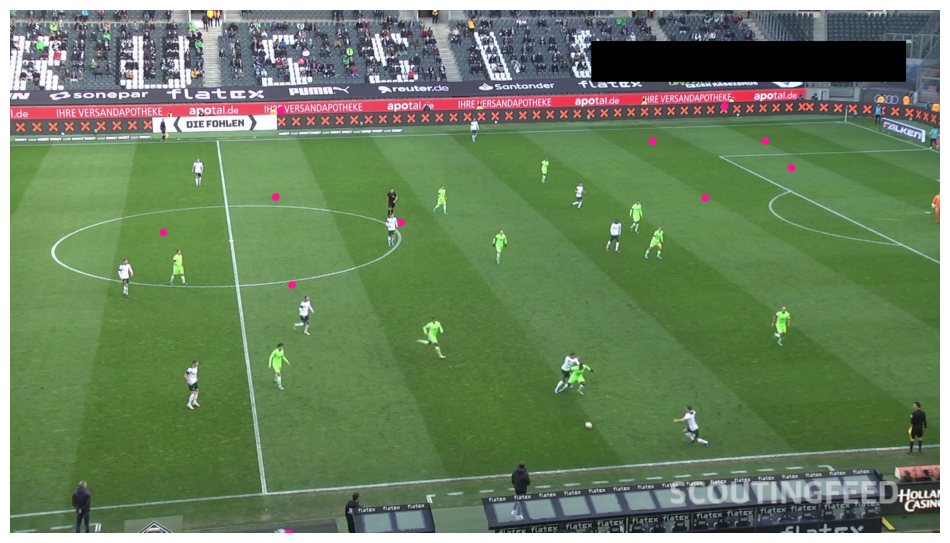

In [18]:
import cv2
import torch
import supervision as sv
from ultralytics import YOLO

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load your YOLO pose model
model = YOLO("models/key_points_detection.pt").to(device)

SOURCE_VIDEO_PATH='test.mp4'

# Load a frame or image
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

# Run inference
results = model(frame, device=device, conf=0.3)[0]

# Convert YOLO pose results to supervision KeyPoints
key_points = sv.KeyPoints.from_ultralytics(results)

filter = key_points.confidence[0] > 0.5
frame_reference_points = key_points.xy[0][filter]
frame_reference_key_points = sv.KeyPoints(
    xy=frame_reference_points[np.newaxis, ...])

# Annotator for keypoints
vertex_annotator = sv.VertexAnnotator(
    color=sv.Color.from_hex('#FF1493'),
    radius=8
)

# Annotate the image with keypoints
annotated_frame = frame.copy()
annotated_frame = vertex_annotator.annotate(
    scene=annotated_frame,
    key_points=frame_reference_key_points
)

# Display annotated image
sv.plot_image(annotated_frame)


In [19]:
import cv2
import torch
import supervision as sv
from ultralytics import YOLO

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load your YOLO pose model
model = YOLO("models/key_points_detection.pt").to(device)

SOURCE_VIDEO_PATH = "test.mp4"
OUTPUT_VIDEO_PATH = "key_points_detected.mp4"

# Create a frame generator from the video
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

# Get video properties for writing output
cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

# Set up video writer
out = cv2.VideoWriter(
    OUTPUT_VIDEO_PATH,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (frame_width, frame_height)
)

# Annotator for keypoints
vertex_annotator = sv.VertexAnnotator(
    color=sv.Color.from_hex('#FF1493'),
    radius=8
)

for frame in frame_generator:
    # Run inference on the current frame
    results = model(frame, device=device, conf=0.3)[0]

    # Convert YOLO pose results to supervision KeyPoints
    if results.keypoints is not None:
        key_points = sv.KeyPoints.from_ultralytics(results)

        # Example filtering keypoints by confidence
        # Assuming first detected instance, adjust indexing as needed if multiple instances
        if len(key_points.confidence) > 0:
            filter_mask = key_points.confidence[0] > 0.5
            frame_reference_points = key_points.xy[0][filter_mask]
            frame_reference_key_points = sv.KeyPoints(
                xy=frame_reference_points[np.newaxis, ...]
            )
        else:
            # If no keypoints or no instances detected, skip annotation
            frame_reference_key_points = None
    else:
        frame_reference_key_points = None

    # Annotate the frame if we have keypoints
    annotated_frame = frame.copy()
    if frame_reference_key_points is not None:
        annotated_frame = vertex_annotator.annotate(
            scene=annotated_frame,
            key_points=frame_reference_key_points
        )

    # Write the annotated frame to the output video
    out.write(annotated_frame)

# Release resources
out.release()

print("Processing complete. Output saved to:", OUTPUT_VIDEO_PATH)



0: 384x640 1 pitch, 18.5ms
Speed: 2.0ms preprocess, 18.5ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 pitch, 17.0ms
Speed: 1.0ms preprocess, 17.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 pitch, 17.0ms
Speed: 2.0ms preprocess, 17.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 pitch, 17.0ms
Speed: 2.0ms preprocess, 17.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 pitch, 16.0ms
Speed: 2.0ms preprocess, 16.0ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 pitch, 16.0ms
Speed: 1.0ms preprocess, 16.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 pitch, 17.0ms
Speed: 1.0ms preprocess, 17.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 pitch, 17.0ms
Speed: 2.0ms preprocess, 17.0ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


In [2]:
import cv2
import numpy as np
from ultralytics import YOLO
import supervision as sv
import torch
from tqdm import tqdm
from sklearn.cluster import KMeans

def extract_average_color(image):
    # Convert image to HSV
    image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # Resize to reduce computation and noise
    image = cv2.resize(image, (32, 32))
    # Compute the mean color
    mean_color = image.mean(axis=(0, 1))
    return mean_color

def classify_player(dominant_color, team_colors):
    # Compute distances to each team color centroid
    distances = np.linalg.norm(team_colors - dominant_color, axis=1)
    # Assign to the closest team
    team_id = np.argmin(distances)
    return team_id

def get_center(box):
    # box format: [x_min, y_min, x_max, y_max]
    x_center = (box[0] + box[2]) / 2
    y_center = (box[1] + box[3]) / 2
    return np.array([x_center, y_center])

def resolve_goalkeepers_team_id(players, goalkeepers):
    if len(goalkeepers) == 0 or len(players) == 0:
        return np.array([])
    goalkeepers_xy = goalkeepers.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
    players_xy = players.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
    team_0_players = players_xy[np.array(players.class_id) == 0]
    team_1_players = players_xy[np.array(players.class_id) == 1]
    team_0_centroid = team_0_players.mean(axis=0) if len(team_0_players) > 0 else np.array([0, 0])
    team_1_centroid = team_1_players.mean(axis=0) if len(team_1_players) > 0 else np.array([0, 0])
    goalkeepers_team_id = []
    for goalkeeper_xy in goalkeepers_xy:
        dist_0 = np.linalg.norm(goalkeeper_xy - team_0_centroid)
        dist_1 = np.linalg.norm(goalkeeper_xy - team_1_centroid)
        if dist_0 == dist_1:
            # Assign to a default team if equidistant
            goalkeepers_team_id.append(0)
        else:
            goalkeepers_team_id.append(0 if dist_0 < dist_1 else 1)
    return np.array(goalkeepers_team_id)

def load_model(model_path, device):
    model = YOLO(model_path)
    model.to(device)
    return model

def extract_team_colors(video_path, model, device, stride=30, max_frames=10):
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    # Constants for class IDs (adjust based on your model)
    PLAYER_ID = 2

    initial_frames = []
    # Collect frames at intervals to sample player colors
    for idx in range(0, frame_count, stride):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            break
        initial_frames.append(frame)
        if len(initial_frames) >= max_frames:
            break

    # Collect dominant colors from initial frames
    dominant_colors = []
    print("Collecting dominant colors from initial frames...")
    for frame in tqdm(initial_frames):
        results = model(frame, device=device)
        result = results[0]
        detections = sv.Detections(
            xyxy=result.boxes.xyxy.cpu().numpy(),
            confidence=result.boxes.conf.cpu().numpy(),
            class_id=result.boxes.cls.cpu().numpy().astype(int)
        )
        players_detections = detections[detections.class_id == PLAYER_ID]
        for xyxy in players_detections.xyxy:
            crop = sv.crop_image(frame, xyxy)
            color = extract_average_color(crop)
            dominant_colors.append(color)

    # Cluster the dominant colors to find team colors
    print("Clustering colors to identify team colors...")
    dominant_colors = np.array(dominant_colors)
    kmeans = KMeans(n_clusters=2, random_state=42)
    kmeans.fit(dominant_colors)
    team_colors = kmeans.cluster_centers_

    cap.release()
    return team_colors

def process_batch(frames, model, device, team_colors, ellipse_annotator, triangle_annotator,
                  out, POSSESSION_THRESHOLD, BALL_ID, GOALKEEPER_ID, PLAYER_ID, REFEREE_ID,
                  team_0_possession_frames, team_1_possession_frames):
    # Run YOLO inference on batch
    results = model(frames, device=device)

    for i, result in enumerate(results):
        detections = sv.Detections(
            xyxy=result.boxes.xyxy.cpu().numpy(),
            confidence=result.boxes.conf.cpu().numpy(),
            class_id=result.boxes.cls.cpu().numpy().astype(int)
        )

        # Separate detections by class
        ball_detections = detections[detections.class_id == BALL_ID]
        ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)
        all_detections = detections[detections.class_id != BALL_ID]

        # Apply Non-Maximum Suppression
        all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True)

        # Separate player, goalkeeper, and referee detections
        goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
        players_detections = all_detections[all_detections.class_id == PLAYER_ID]
        referees_detections = all_detections[all_detections.class_id == REFEREE_ID]

        # Extract crops and classify players by team
        team_ids = []
        for xyxy in players_detections.xyxy:
            crop = sv.crop_image(frames[i], xyxy)
            dominant_color = extract_average_color(crop)
            team_id = classify_player(dominant_color, team_colors)
            team_ids.append(team_id)

        # Assign team IDs to player detections
        players_detections.class_id = np.array(team_ids)

        # Assign team IDs to goalkeepers
        goalkeepers_detections.class_id = resolve_goalkeepers_team_id(players_detections, goalkeepers_detections)

        # Merge detections
        all_detections = sv.Detections.merge([players_detections, goalkeepers_detections, referees_detections])

        # Determine ball possession
        if len(ball_detections) > 0 and len(players_detections) > 0:
            ball_center = get_center(ball_detections.xyxy[0])
            player_centers = np.array([get_center(box) for box in players_detections.xyxy])
            distances = np.linalg.norm(player_centers - ball_center, axis=1)
            min_dist_idx = np.argmin(distances)
            min_dist = distances[min_dist_idx]

            if min_dist < POSSESSION_THRESHOLD:
                ball_holder_team_id = players_detections.class_id[min_dist_idx]
                if ball_holder_team_id == 0:
                    team_0_possession_frames += 1
                elif ball_holder_team_id == 1:
                    team_1_possession_frames += 1

        frame_bgr = cv2.cvtColor(frames[i], cv2.COLOR_RGB2BGR)
        annotated_frame = ellipse_annotator.annotate(
            scene=frame_bgr,
            detections=all_detections
        )
        annotated_frame = triangle_annotator.annotate(
            scene=annotated_frame,
            detections=ball_detections
        )
        out.write(annotated_frame)

    return team_0_possession_frames, team_1_possession_frames

def process_video(video_path, output_path, model, device, team_colors):
    # Constants for class IDs (assuming your model's class order)
    BALL_ID = 0
    GOALKEEPER_ID = 1
    PLAYER_ID = 2
    REFEREE_ID = 3

    # Annotators
    ellipse_annotator = sv.EllipseAnnotator(
        color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
        thickness=2
    )
    label_annotator = sv.LabelAnnotator(
        color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
        text_color=sv.Color.from_hex('#000000'),
        text_position=sv.Position.BOTTOM_CENTER
    )
    triangle_annotator = sv.TriangleAnnotator(
        color=sv.Color.from_hex('#FFD700'),
        base=25,
        height=21,
        outline_thickness=1
    )

    cap = cv2.VideoCapture(video_path)
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

    # Variables for possession tracking
    team_0_possession_frames = 0
    team_1_possession_frames = 0

    # Threshold for possession (distance in pixels)
    POSSESSION_THRESHOLD = 50

    frames = []
    batch_size = 16

    print("Processing video and classifying players...")
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

        if len(frames) == batch_size:
            team_0_possession_frames, team_1_possession_frames = process_batch(
                frames, model, device, team_colors,
                ellipse_annotator, triangle_annotator,
                out, POSSESSION_THRESHOLD, BALL_ID, GOALKEEPER_ID, PLAYER_ID, REFEREE_ID,
                team_0_possession_frames, team_1_possession_frames
            )
            frames = []

    # Process any leftover frames
    if len(frames) > 0:
        team_0_possession_frames, team_1_possession_frames = process_batch(
            frames, model, device, team_colors,
            ellipse_annotator, triangle_annotator,
            out, POSSESSION_THRESHOLD, BALL_ID, GOALKEEPER_ID, PLAYER_ID, REFEREE_ID,
            team_0_possession_frames, team_1_possession_frames
        )

    cap.release()
    out.release()

    # Calculate ball possession percentages
    total_possession_frames = team_0_possession_frames + team_1_possession_frames
    if total_possession_frames > 0:
        team_0_possession_percent = (team_0_possession_frames / total_possession_frames) * 100
        team_1_possession_percent = (team_1_possession_frames / total_possession_frames) * 100
    else:
        team_0_possession_percent = 0
        team_1_possession_percent = 0

    return team_0_possession_percent, team_1_possession_percent

def main(video_path, output_path, model_path="models/player_detection.pt"):
    # Set up GPU device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Load model
    model = load_model(model_path, device)

    # Extract team colors from initial frames
    team_colors = extract_team_colors(video_path, model, device)

    # Process the full video
    team_0_possession_percent, team_1_possession_percent = process_video(
        video_path, output_path, model, device, team_colors
    )

    print("Processing complete. Output video saved to:", output_path)
    print(f"Team 0 Possession: {team_0_possession_percent:.2f}%")
    print(f"Team 1 Possession: {team_1_possession_percent:.2f}%")

if __name__ == "__main__":
    # Example usage:
    # main("test.mp4", "ball_possession.mp4")
    main("test.mp4", "ball_possession.mp4")


  0%|          | 0/10 [00:00<?, ?it/s]


0: 736x1280 1 ball, 1 goalkeeper, 20 players, 3 referees, 56.1ms
Speed: 5.0ms preprocess, 56.1ms inference, 1.0ms postprocess per image at shape (1, 3, 736, 1280)


 10%|█         | 1/10 [00:00<00:03,  2.97it/s]


0: 736x1280 1 ball, 20 players, 3 referees, 27.1ms
Speed: 6.1ms preprocess, 27.1ms inference, 1.0ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 1 ball, 20 players, 2 referees, 26.6ms
Speed: 4.5ms preprocess, 26.6ms inference, 2.5ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 1 ball, 20 players, 2 referees, 26.5ms
Speed: 5.0ms preprocess, 26.5ms inference, 1.0ms postprocess per image at shape (1, 3, 736, 1280)


 40%|████      | 4/10 [00:00<00:00, 10.68it/s]

...


0: 736x1280 1 ball, 21 players, 3 referees, 26.6ms
Speed: 5.0ms preprocess, 26.6ms inference, 2.0ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 20 players, 3 referees, 26.0ms
Speed: 5.5ms preprocess, 26.0ms inference, 1.0ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 1 ball, 21 players, 3 referees, 26.4ms
Speed: 5.0ms preprocess, 26.4ms inference, 1.0ms postprocess per image at shape (1, 3, 736, 1280)


100%|██████████| 10/10 [00:00<00:00, 14.98it/s]

Clustering colors to identify team colors...
Processing video and classifying players...



0: 736x1280 1 ball, 1 goalkeeper, 20 players, 4 referees, 29.8ms
1: 736x1280 1 ball, 1 goalkeeper, 20 players, 4 referees, 29.8ms
2: 736x1280 1 ball, 1 goalkeeper, 20 players, 4 referees, 29.8ms
3: 736x1280 1 ball, 1 goalkeeper, 20 players, 4 referees, 29.8ms
4: 736x1280 1 ball, 1 goalkeeper, 21 players, 4 referees, 29.8ms
5: 736x1280 1 ball, 1 goalkeeper, 20 players, 4 referees, 29.8ms
6: 736x1280 1 ball, 1 goalkeeper, 20 players, 4 referees, 29.8ms
7: 736x1280 1 ball, 1 goalkeeper, 21 players, 4 referees, 29.8ms
8: 736x1280 1 ball, 1 goalkeeper, 22 players, 3 referees, 29.8ms
9: 736x1280 1 ball, 1 goalkeeper, 22 players, 4 referees, 29.8ms
10: 736x1280 1 ball, 1 goalkeeper, 20 players, 4 referees, 29.8ms
11: 736x1280 1 ball, 22 players, 4 referees, 29.8ms
12: 736x1280 1 ball, 21 players, 4 referees, 29.8ms
13: 736x1280 1 ball, 21 players, 4 referees, 29.8ms
14: 736x1280 1 ball, 22 players, 4 referees, 29.8ms
15: 736x1280 1 ball, 20 players, 4 referees, 29.8ms
Speed: 5.9ms preprocess

KeyboardInterrupt: 